In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df_wine = pd.read_csv(
    "https://archive.ics.uci.edu/ml/machine-learning-databases/wine/wine.data",
    header=None,
)

In [3]:
df_wine.columns = [
    "Class label",
    "Alcohol",
    "Malic acid",
    "Ash",
    "Alcalinity of ash",
    "Magnesium",
    "Total phenols",
    "Flavanoids",
    "Nonflavanoid phenols",
    "Proanthocyanins",
    "Color intensity",
    "Hue",
    "OD280/OD315 of diluted wines",
    "Proline",
]

print("Class labels: ", np.unique(df_wine["Class label"]))
print(df_wine.shape)

Class labels:  [1 2 3]
(178, 14)


In [4]:
df_wine.head()

,Class label,Alcohol,Malic acid,Ash,Alcalinity of ash,Magnesium,Total phenols,Flavanoids,Nonflavanoid phenols,Proanthocyanins,Color intensity,Hue,OD280/OD315 of diluted wines,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [5]:
from sklearn.model_selection import train_test_split

X, y = df_wine.iloc[:, 1:].values, df_wine.iloc[:, 0].values
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=0, stratify=y
)

In [6]:
from sklearn.preprocessing import MinMaxScaler

mms = MinMaxScaler()
X_train_norm = mms.fit_transform(X_train)
X_test_norm = mms.fit_transform(X_test)

In [7]:
from sklearn.preprocessing import StandardScaler

stdsc = StandardScaler()
X_train_std = stdsc.fit_transform(X_train)
X_test_std = stdsc.transform(X_test)

#### L1 and L2 Regularization

In [8]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(penalty="l1", solver="liblinear", multi_class="ovr", C=1.0)
lr.fit(X_train_std, y_train)

/home/slayer0x10/dev/ml/ml-study/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(multi_class='ovr', penalty='l1', solver='liblinear')

In [9]:
print("Training Accuracy: ", lr.score(X_train_std, y_train))
print("Test Accuracy: ", lr.score(X_test_std, y_test))

Training Accuracy:  1.0
Test Accuracy:  1.0


In [10]:
lr.coef_

array([[ 1.24551433,  0.18010146,  0.74633096, -1.16396562,  0.        ,
         0.        ,  1.15891693,  0.        ,  0.        ,  0.        ,
         0.        ,  0.55707151,  2.50909484],
       [-1.53726524, -0.38710213, -0.99516187,  0.36479311, -0.05967609,
         0.        ,  0.66821347,  0.        ,  0.        , -1.9339777 ,
         1.23365376,  0.        , -2.23186561],
       [ 0.13576291,  0.16826108,  0.35742375,  0.        ,  0.        ,
         0.        , -2.43755498,  0.        ,  0.        ,  1.56354668,
        -0.81959696, -0.49237581,  0.        ]])

---
### Feature Selection : Sequential Backward Selection (SBS)

- at each stage we eliminate the feature that causes the least performance loss after removal.

In [24]:
from sklearn.base import clone
from sklearn.metrics import accuracy_score
from itertools import combinations


class SBS:
    def __init__(
        self,
        estimator,
        k_features,
        scoring=accuracy_score,
        test_size=0.25,
        random_state=1,
    ) -> None:
        self.scoring = scoring
        self.estimator = clone(estimator)
        self.k_features = k_features
        self.test_size = test_size
        self.random_state = random_state

    def fit(self, X, y):
        X_train, X_test, y_train, y_test = train_test_split(
            X,
            y,
            test_size=self.test_size,
            random_state=self.random_state,
        )

        dim = X_train.shape[1]
        self.indices_ = tuple(range(dim))
        self.subsets_ = [self.indices_]
        score = self._calc_score(X_train, y_train, X_test, y_test, self.indices_)
        self.scores_ = [score]

        while dim > self.k_features:
            scores = []
            subsets = []

            for p in combinations(self.indices_, r=dim - 1):
                score = self._calc_score(X_train, y_train, X_test, y_test, p)
                scores.append(score)
                subsets.append(p)

            best = np.argmax(scores)
            self.indices_ = subsets[best]
            self.subsets_.append(self.indices_)
            dim -= 1

            self.scores_.append(scores[best])

        self.k_score_ = self.scores_[-1]
        return self

    def transform(self, X):
        return X[:, self.indices_]

    def _calc_score(self, X_train, y_train, X_test, y_test, indices):
        self.estimator.fit(X_train[:, indices], y_train)
        y_pred = self.estimator.predict(X_test[:, indices])
        score = self.scoring(y_test, y_pred)
        return score


In [34]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
sbs = SBS(knn, k_features=2)
sbs.fit(X_train_std, y_train)

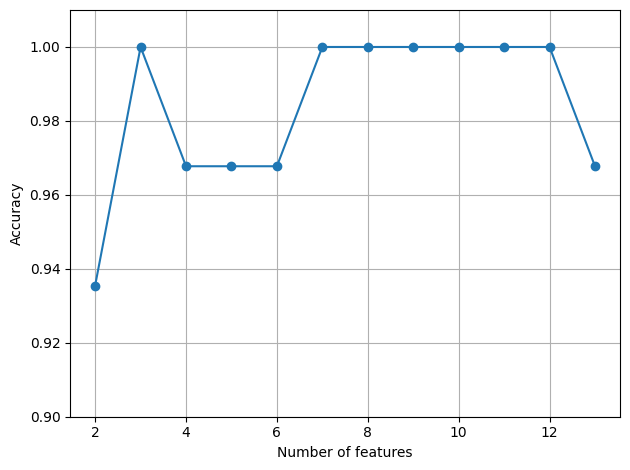

In [39]:
k_feat = [len(k) for k in sbs.subsets_]
plt.plot(k_feat, sbs.scores_, marker="o")
plt.ylim([0.9, 1.01])

plt.ylabel("Accuracy")
plt.xlabel("Number of features")
plt.grid()
plt.tight_layout()
plt.show()

In [41]:
k3 = list(sbs.subsets_[10])
print(df_wine.columns[1:][k3])

Index(['Alcohol', 'Malic acid', 'OD280/OD315 of diluted wines'], dtype='object')


In [ ]:
knn.fit(X_train_std, y_train)
print("Training Accuracy: ", knn.score(X_train_std, y_train))
print("Test Accuracy: ", knn.score(X_test_std, y_test))

Training Accuracy:  0.967741935483871
Test Accuracy:  0.9629629629629629


In [43]:
knn.fit(X_train_std[:, k3], y_train)
print("K3 Training Accuracy: ", knn.score(X_train_std[:, k3], y_train))
print("K3 Test Accuracy: ", knn.score(X_test_std[:, k3], y_test))

K3 Training Accuracy:  0.9516129032258065
K3 Test Accuracy:  0.9259259259259259


---
### Assessing feature importance with `RandomForests`
- If two or more features are highly correlated, one feature may
be ranked very highly while the information on the other feature(s) may not be fully captured.
- On the other hand, we don’t need to be concerned about this problem if we are merely interested in the
predictive performance of a model rather than the interpretation of feature importance values.

In [44]:
from sklearn.ensemble import RandomForestClassifier

feat_labels = df_wine.columns[1:]
forest = RandomForestClassifier(n_estimators=500, random_state=1, n_jobs=-1)

forest.fit(X_train, y_train)
importances = forest.feature_importances_
indices = np.argsort(importances)[::-1]

 1) Proline                        0.185453
 2) Flavanoids                     0.174751
 3) Color intensity                0.143920
 4) OD280/OD315 of diluted wines   0.136162
 5) Alcohol                        0.118529
 6) Hue                            0.058739
 7) Total phenols                  0.050872
 8) Magnesium                      0.031357
 9) Malic acid                     0.025648
10) Proanthocyanins                0.025570
11) Alcalinity of ash              0.022366
12) Nonflavanoid phenols           0.013354
13) Ash                            0.013279


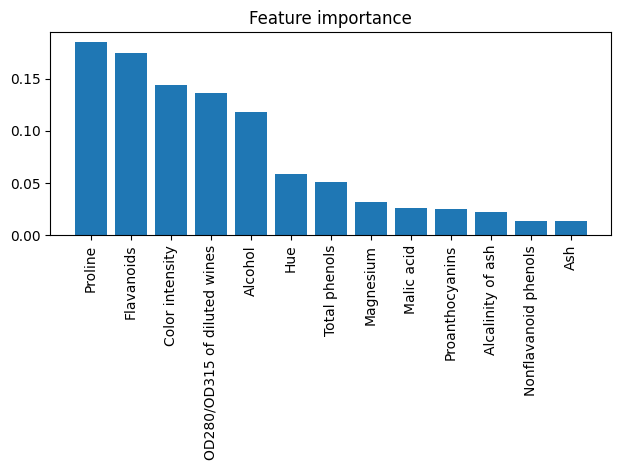

In [45]:
for f in range(X_train.shape[1]):
    print(
        "%2d) %-*s %f" % (f + 1, 30, feat_labels[indices[f]], importances[indices[f]])
    )

plt.title("Feature importance")
plt.bar(range(X_train.shape[1]), importances[indices], align="center")

plt.xticks(range(X_train.shape[1]), feat_labels[indices], rotation=90)
plt.xlim([-1, X_train.shape[1]])
plt.tight_layout()
# plt.savefig('figures/04_10.png', dpi=300)
plt.show()